In [14]:
import torch
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import numpy as np
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from xFNO import *
from special_loss_functions import *

random.seed(100)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [15]:
def train(dataloader, model, loss_fn, optimizer, device):
    num_batches = len(dataloader)
    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)     
        pred = model(X)
        loss = loss_fn(pred, y)
        train_loss += loss.item()
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    loss /= num_batches
    return loss

def test(dataloader, model, loss_fn, device):
    num_batches = len(dataloader)
    model.eval()
    loss = 0
    with torch.no_grad():   
        for batch, (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss += loss_fn(pred, y).item()
    loss /= num_batches
    return loss

In [18]:
# inputs [B, Nx, Nf]
# outputs [B, Nx, Nt, Nf]
def make_training_testing_datasets(data, history, batch_size, training_size=400, shuffle_flag=True):

    # select
    features = torch.tensor(data[:-history, ...])
    labels = [torch.permute(torch.tensor(data[i+1:i+1+history, ...]), (1, 2, 0)) for i in range(data.shape[0]-history)]

    # re-arrange
    features = torch.reshape(features, features.shape + (1,)).to(torch.float32)
    labels = torch.stack(labels)
    labels = torch.reshape(labels, labels.shape + (1,)).to(torch.float32)

    # create datasets
    if shuffle_flag: idx = torch.randperm(training_size)
    else: idx = np.arange(training_size)
    training_dataset = TensorDataset(features[idx, ...], labels[idx, ...])
    testing_dataset = TensorDataset(features[training_size:, ...], labels[training_size:, ...])

    # create dataloaders
    training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
    testing_dataloader = DataLoader(testing_dataset, batch_size=batch_size, shuffle=True)

    dimensions = labels.shape
    
    return training_dataloader, testing_dataloader, dimensions

(1401, 32, 32)
0.003916167676860913


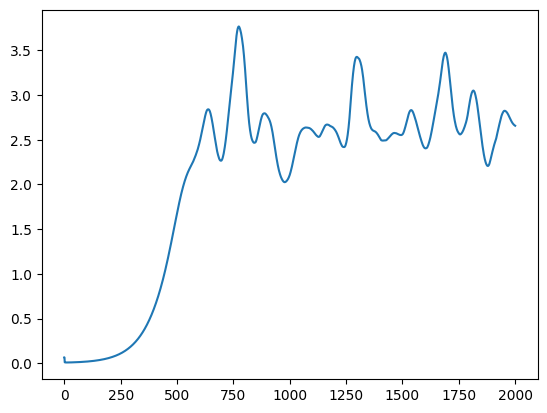

In [19]:
# Load PDE solution
N = 32
with open(f'data/KuramotoSivashinsky/KS2D_Nx{N}_Ny{N}_8pi.pkl', 'rb') as file:
    data = pickle.load(file)

a = np.mean(np.abs(data), axis=(1, 2))
plt.plot(a)
# remove wind-up period
data = data[600:,  ...]
print(data.shape)
mass_data = np.median(np.mean(data, axis = (1, 2)))
print(mass_data)

In [20]:
# create data structures
history = 5
batch_size = 64
training_dataloader, testing_dataloader, dimensions = make_training_testing_datasets(data, history, batch_size, 1000, True)
print(dimensions)

torch.Size([1396, 32, 32, 5, 1])


In [21]:
# initialize operator
Nf = dimensions[-1]
Nx = dimensions[1]
Ny = dimensions[2]
Nlifted = 16
Nk_truncated = 10
depth = history

neuralop = PFNO(
            (Nx, Ny, Nf), 
            Nlifted, 
            (Nk_truncated, Nk_truncated,), 
            depth,
            mass=mass_data
            ).to(device) 

loss_fn_test = torch.nn.MSELoss(reduction='mean') 
loss_fn = H1Loss_Huber(reduction='mean', dim=(1,2)) 

#loss_fn = torch.nn.MSELoss(reduction='mean')
#loss_fn_test = torch.nn.MSELoss(reduction='mean')

rate = 2e-04 #1e-04
optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)

Train Loss: 0.17628, Test Loss: 10.85741
Train Loss: 0.00322, Test Loss: 0.07895
Train Loss: 0.00052, Test Loss: 0.01643
Train Loss: 0.00114, Test Loss: 0.01080
Train Loss: 0.00033, Test Loss: 0.00835
final learning rate: 6.553600000000003e-05


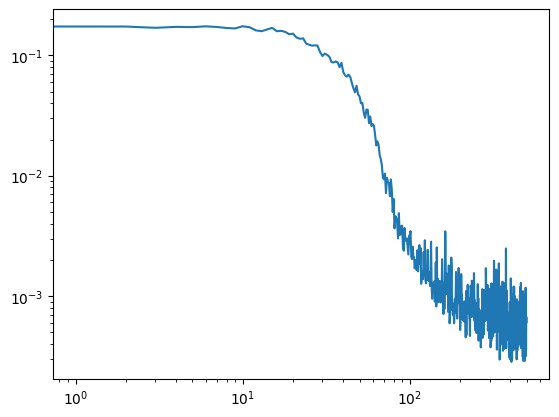

In [22]:
# train
testing_loss = []
training_loss = []
epochs = 500
for i in range(epochs):
    training_loss += [train(training_dataloader, neuralop, loss_fn, optimizer_neuralop, device).detach()]
    if i%100==0:
        testing_loss += [test(testing_dataloader, neuralop, loss_fn_test, device)]
        print(f"Train Loss: {(training_loss[-1]):>0.5f}, Test Loss: {(testing_loss[-1]):>0.5f}")        
        rate *= 0.8
        optimizer_neuralop = torch.optim.Adam(neuralop.parameters(), lr=rate)

print(f'final learning rate: {rate}')
plt.figure()
plt.plot(training_loss)
plt.loglog()
PATH = f"models/KS2D/PFNO2D_N{N}.pth"
torch.save(neuralop.state_dict(), PATH)
param_list = [(Nx, Ny, Nf), Nlifted, (Nk_truncated,Nk_truncated), depth]
PARAM_PATH=f"models/KS2D/PFNO2D_parameters_N{N}"
with open(PARAM_PATH, 'wb') as f:
    pickle.dump(param_list, f)

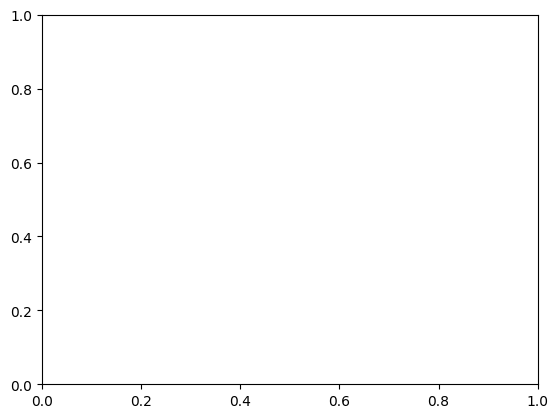

In [23]:
N = 32
suffix='_8pi'
history = 5
Nx = N
Ny = N
with open(f"data/KuramotoSivashinsky/KS2D_Nx{N}_Ny{N}{suffix}.pkl", 'rb') as file:
    data = pickle.load(file)
# remove wind-up period
data = data[600:,  ...]
mass_data = np.median(np.mean(data, axis = (1, 2)))

PATH = f"models/KS2D/PFNO2D_N{N}.pth"
PARAM_PATH=f"models/KS2D/PFNO2D_parameters_N{N}"
with open(PARAM_PATH, 'rb') as f:
    params = pickle.load(f)
neuralop = PFNO(*params, mass=mass_data).to(device) 
weights = torch.load(PATH, weights_only=True)
neuralop.load_state_dict(weights)

neuralop.eval()
fig, ax = plt.subplots()
data = torch.tensor(data)
training_size = 1
cmax = 7
x = np.linspace(0, 16*np.pi, N, endpoint=False)
y = np.linspace(0, 16*np.pi, N, endpoint=False)
loss_fn_plot = H1Loss_Huber(reduction='mean', dim=(0,)) 
t = 0
for i in range(0, data[training_size:-history, ...].size()[0]-1, history):
    t+=1
    uin = torch.reshape(data[training_size+i, ...].to(torch.float32), (1, Nx, Ny, 1))
    
    u_pred = neuralop(uin) # don't extrapolate, recompute prediction    
    u_pred = u_pred.detach().squeeze()
    u_target = torch.permute(data[i+training_size+1:i+training_size+history+1, ...], (1, 2, 0))
    mass = torch.mean(u_pred[..., -1])
    mass_target = torch.mean(u_target[..., -1])
    loss = loss_fn_plot(u_pred, u_target)
    
    #clear_output(wait=True)
    #print(f'mass of estimate: {mass:0.5f}, mass of solution: {mass_target:0.5f}, loss: {loss}')
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
    pc1 = ax1.pcolormesh(x, y, u_target[..., -1], vmin = -cmax, vmax = cmax, cmap='RdBu_r', shading='gouraud')
    pc2 = ax2.pcolormesh(x, y, u_pred[..., -1], vmin = -cmax, vmax = cmax, cmap='RdBu_r', shading='gouraud')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax2.set_xlabel('x')
    ax1.set_aspect('equal')
    ax2.set_aspect('equal')
    fig.colorbar(pc2, shrink=0.5)
    fig.colorbar(pc1, shrink=0.5)
    #plt.show()
    
    plt.savefig(f'frames/frame_{t:03d}.png', transparent=True, bbox_inches='tight')
    plt.close(fig)

    #plt.pause(0.05)
    

In [24]:
import imageio.v2 as imageio
import os
frames = []
for ti in range(t):
    image = imageio.imread(f'frames/frame_{ti+1:03d}.png')
    frames.append(image)

# Save the list of frames as a GIF
imageio.mimsave(f'KS2D_N{N}_PFNO.gif', frames, fps=10) # `fps` controls the speed

# Clean up the individual frame files (optional)
for ti in range(t):
    os.remove(f'frames/frame_{ti+1:03d}.png')

In [1]:
N = 32
suffix='_8pi'
history = 5
Nx = N
Ny = N
with open(f"data/KuramotoSivashinsky/KS2D_Nx64_Ny64{suffix}.pkl", 'rb') as file:
    data = pickle.load(file)
# remove wind-up period
data = data[600:,  ::2, ::2]
mass_data = np.median(np.mean(data, axis = (1, 2)))

PATH = f"models/KS2D/PFNO2D_N{N}.pth"
PARAM_PATH=f"models/KS2D/PFNO2D_parameters_N{N}"
with open(PARAM_PATH, 'rb') as f:
    params = pickle.load(f)
neuralop = PFNO(*params, mass=mass_data).to(device) 
weights = torch.load(PATH, weights_only=True)
neuralop.load_state_dict(weights)

neuralop.eval()
fig, ax = plt.subplots()
data = torch.tensor(data)
training_size = 0
cmax = 7
x = np.linspace(0, 16*np.pi, N, endpoint=False)
y = np.linspace(0, 16*np.pi, N, endpoint=False)
loss_fn_plot = H1Loss_Huber(reduction='mean', dim=(0,)) 
t = 0
for i in range(0, data[training_size:-history, ...].size()[0]-1, history):
    t+=1
    uin = torch.reshape(data[training_size+i, ...].to(torch.float32), (1, Nx, Ny, 1))
    
    u_pred = neuralop(uin) # don't extrapolate, recompute prediction    
    u_pred = u_pred.detach().squeeze()
    u_target = torch.permute(data[i+training_size+1:i+training_size+history+1, ...], (1, 2, 0))
    mass = torch.mean(u_pred[..., -1])
    mass_target = torch.mean(u_target[..., -1])
    loss = loss_fn_plot(u_pred, u_target)
    
    #clear_output(wait=True)
    #print(f'mass of estimate: {mass:0.5f}, mass of solution: {mass_target:0.5f}, loss: {loss}')
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
    pc1 = ax1.pcolormesh(x, y, u_target[..., -1], vmin = -cmax, vmax = cmax, cmap='RdBu_r', shading='gouraud')
    pc2 = ax2.pcolormesh(x, y, u_pred[..., -1], vmin = -cmax, vmax = cmax, cmap='RdBu_r', shading='gouraud')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax2.set_xlabel('x')
    ax1.set_aspect('equal')
    ax2.set_aspect('equal')
    fig.colorbar(pc2, shrink=0.5)
    fig.colorbar(pc1, shrink=0.5)
    #plt.show()
    
    plt.savefig(f'frames/frame_{t:03d}.png', transparent=True, bbox_inches='tight')
    plt.close(fig)
    

    #plt.pause(0.05)

import imageio.v2 as imageio
import os
frames = []
for ti in range(t):
    image = imageio.imread(f'frames/frame_{ti+1:03d}.png')
    frames.append(image)

# Save the list of frames as a GIF
imageio.mimsave(f'KS2D_N{N}_PFNO_downsample.gif', frames, fps=10) # `fps` controls the speed

# Clean up the individual frame files (optional)
for ti in range(t):
    os.remove(f'frames/frame_{ti+1:03d}.png')

NameError: name 'pickle' is not defined

In [25]:
mass_data

np.float64(0.003916167676860913)